## Cél

Ez a notebook a `quant_train` tábla feature-jeinek szisztematikus minőségellenőrzését végzi solusdt, 1m bontásban.
A 4 elemzési lépés sorban fut: **quality → target_relation → redundancy → stability**.
Az eredmény determinisztikusan kerül a `feature_set.json`-be — nincs manuális szerkesztés.

**Kapcsolódó dokumentáció:**
- Módszertan: `_doc_/2000_features.md`
- Kód-dokumentáció: `_doc_/2010_feature_engineering.md`

**Asset:** SOLUSDT | **Granularitás:** 1m | **Dátum:** 2026-06-19

In [1]:
import sys
import json
import logging
from pathlib import Path
from datetime import datetime

import duckdb
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(_root / "src"))

import utils
from analyst.table_formatting import display_analysis_table
from modeling.feature_engineering import (
    FeatureEngineeringConfig,
    analyze_quality,
    analyze_target_relation,
    analyze_redundancy,
    analyze_stability,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)

CQ_COLORS = {
    "blue":       "#1696d2",
    "black":      "#000000",
    "gray_dark":  "#353535",
    "gray":       "#696969",
    "gray_light": "#d2d2d2",
    "yellow":     "#fdbf11",
    "orange":     "#f15a24",
    "red":        "#ec008b",
    "green":      "#55b748",
}
CQ_SEQUENCE = [
    CQ_COLORS["blue"], CQ_COLORS["yellow"], CQ_COLORS["orange"],
    CQ_COLORS["gray"], CQ_COLORS["red"],
]
DECISION_COLORS = {
    "keep":   CQ_COLORS["green"],
    "review": CQ_COLORS["yellow"],
    "drop":   CQ_COLORS["red"],
}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize":    (9, 5),
        "figure.dpi":        120,
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.edgecolor":    CQ_COLORS["gray"],
        "axes.labelcolor":   CQ_COLORS["gray_dark"],
        "xtick.color":       CQ_COLORS["gray_dark"],
        "ytick.color":       CQ_COLORS["gray_dark"],
        "grid.color":        CQ_COLORS["gray_light"],
        "grid.linewidth":    0.8,
        "axes.axisbelow":    True,
        "legend.frameon":    False,
    },
)
sns.set_palette(CQ_SEQUENCE)

In [ ]:
# papermill parameters — overridden at runtime by pipeline.py
ARTIFACT_DIR = ""
SAMPLE_DIR   = ""
MODEL_ID     = ""

In [ ]:
RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")

# Derive asset_id and model direction from MODEL_ID
# Format: lgbm_{asset}_{direction}_fw{horizon}_q{quantile}_{year}
ASSET_ID   = MODEL_ID.split("_")[1] if MODEL_ID else "solusdt"
_direction = MODEL_ID.split("_")[2] if MODEL_ID else "l"
_target    = "long_mfe_fw60" if _direction == "l" else "short_mfe_fw60"

_asset_cfg = utils.load_asset_config(ASSET_ID)
_db_path   = _asset_cfg["database"]["db_path"]

# Get sample date boundaries (sample parquet has open_time + targets, no feat_*)
_sample_path = Path(SAMPLE_DIR) / "sample_train_valid.parquet"
_sample_df   = pl.read_parquet(_sample_path)
_min_time    = _sample_df["open_time"].min()
_max_time    = _sample_df["open_time"].max()

# Load quant_train for this model's year only from live DB
_live_conn = duckdb.connect(_db_path, read_only=True)
_qt_df = _live_conn.execute(
    "SELECT * FROM quant_train WHERE open_time >= ? AND open_time <= ?",
    [_min_time, _max_time],
).pl()
_live_conn.close()

# In-memory DuckDB -- only this model's year exposed as 'quant_train'
conn = duckdb.connect(":memory:")
conn.register("_qt", _qt_df)
conn.execute("CREATE TABLE quant_train AS SELECT * FROM _qt")

output_dir = Path(ARTIFACT_DIR) / "feature_engineering"
output_dir.mkdir(parents=True, exist_ok=True)

cfg    = FeatureEngineeringConfig(asset_id=ASSET_ID, run_id=RUN_ID, target_cols=(_target,))
n_rows = conn.execute("SELECT COUNT(*) FROM quant_train").fetchone()[0]

display(Markdown(f"""
| Paraméter | Érték |
|-----------|-------|
| model_id  | `{MODEL_ID}` |
| direction | `{_direction}` → target: `{_target}` |
| sample    | `{SAMPLE_DIR}` |
| time_range| `{_min_time}` -- `{_max_time}` |
| run_id    | `{RUN_ID}` |
| output    | `{output_dir}` |
| sorok     | **{n_rows:,}** |
"""))

## Quality — Univariáns minőség szűrés

**Mi ez.** Minden `feat_*` oszlopra kiszámítjuk a null arányt, az inf értékek arányát, a varianciát és az outlier hányadot (|z-score| > 3).

**Forrás.** `quant_train` tábla, összes `feat_*` oszlop.

**Értelmezés.** `drop` = null_rate > 0.01 VAGY inf_rate > 0.001 VAGY variance < 1e-8; `review` = outlier_ratio > 0.05 (és nincs drop ok); `keep` = minden más. Az első 1441 sor null az t-1 lag warmup miatt — ez nem minőségi hiba, a sampling garantálja, hogy ezek nem kerülnek a tanítási ablakba.

In [3]:
#| label: tbl-quality-decisions
#| tbl-cap: "Feature quality döntések — összes feature"

quality_df = analyze_quality(conn, cfg)
display_analysis_table(quality_df.to_pandas())

12:25:55  INFO  analyze_quality: 208 features, 3022801 rows


12:28:48  INFO  analyze_quality: done — keep=204 drop=2 review=2


feature,null_rate,inf_rate,variance,outlier_ratio,decision,drop_reason
feat_rsi_14,0.00%,0.00%,130.368,0.28%,keep,nan
feat_roc_14,0.00%,0.00%,0.398,1.64%,keep,nan
feat_roc_140,0.00%,0.00%,3.722,1.75%,keep,nan
feat_stoch_k_14,0.00%,0.00%,891.095,0.00%,keep,nan
feat_stoch_d_14,0.00%,0.00%,765.379,0.00%,keep,nan
feat_williams_r_14,0.00%,0.00%,891.095,0.00%,keep,nan
feat_cci_20,0.00%,0.00%,12367.362,0.21%,keep,nan
feat_adx_pos_14,0.00%,0.00%,59.275,0.59%,keep,nan
feat_adx_neg_14,0.00%,0.00%,59.979,0.56%,keep,nan
feat_adx_14,0.00%,0.00%,104.861,1.09%,keep,nan


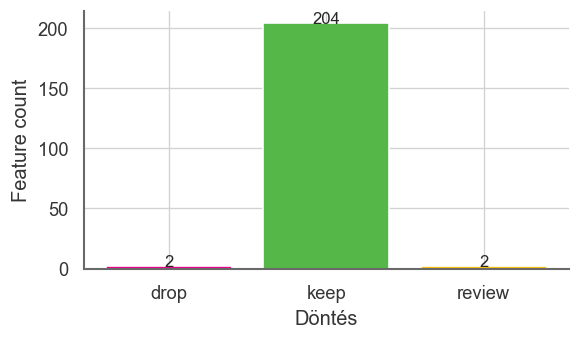

In [4]:
#| label: fig-quality-decisions
#| fig-cap: "Quality döntések megoszlása"
#| fig-alt: "Oszlopdiagram: keep/review/drop döntések száma"

vc = quality_df["decision"].value_counts().sort("decision")
labels = vc["decision"].to_list()
counts = vc["count"].to_list()

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(labels, counts, color=[DECISION_COLORS.get(l, CQ_COLORS["gray"]) for l in labels])
ax.set_xlabel("Döntés")
ax.set_ylabel("Feature count")
for i, v in enumerate(counts):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

In [5]:
#| label: tbl-quality-nokeep
#| tbl-cap: "Nem-keep quality döntések részletei"

not_keep_q = quality_df.filter(pl.col("decision") != "keep").select(
    ["feature", "null_rate", "inf_rate", "variance", "outlier_ratio", "decision", "drop_reason"]
).sort("decision")

display(Markdown(f"**Nem-keep features:** {len(not_keep_q)}"))
display_analysis_table(not_keep_q.to_pandas())

**Nem-keep features:** 4

feature,null_rate,inf_rate,variance,outlier_ratio,decision,drop_reason
feat_gap_open_abs_sma_10,0.00%,0.00%,0.000,2.03%,drop,variance=7.80e-09 < min=1e-08
feat_gap_open_abs_sma_30,0.00%,0.00%,0.000,2.09%,drop,variance=6.76e-09 < min=1e-08
feat_doji,0.02%,0.00%,0.086,9.53%,review,nan
feat_outside_bar,0.00%,0.00%,0.073,7.97%,review,nan


## Target Relation — Szignálerősség

**Mi ez.** Minden `feat_*` × target párra Pearson és Spearman korrelációt számítunk a `quant_train` táblán. `signal_proxy = |ρ_spearman|`.

**Forrás.** `quant_train` tábla, `feat_*` és `long_mfe_fw60`, `short_mfe_fw60` oszlopok.

**Értelmezés.** `leakage` = |ρ| > 0.95 (gyanús); `weak` = |ρ| < 0.01 (nincs szignál); `keep` = minden más. Egy feature akkor kerül ki, ha **mindkét** targetre `weak` (vagy `leakage`).

In [6]:
#| label: tbl-relation-head
#| tbl-cap: "Target relation — top 10 sor (signal_proxy szerint rendezve)"

relation_df = analyze_target_relation(conn, cfg)
display_analysis_table(
    relation_df.sort("signal_proxy", descending=True).head(10).to_pandas()
)

12:28:51  INFO  analyze_target_relation: 208 features × 2 targets


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

12:37:35  INFO  analyze_target_relation: done — keep=258 weak=158 leakage=0


feature,target,pearson_r,spearman_rho,signal_proxy,leakage_flag,decision
feat_natr_14,long_mfe_fw60,0.455,0.362,0.362,False,keep
feat_parkinson_vol_60,long_mfe_fw60,0.449,0.358,0.358,False,keep
feat_gk_vol_60,long_mfe_fw60,0.448,0.356,0.356,False,keep
feat_parkinson_vol_30,long_mfe_fw60,0.446,0.356,0.356,False,keep
feat_gk_vol_30,long_mfe_fw60,0.446,0.355,0.355,False,keep
feat_natr_14,short_mfe_fw60,-0.405,-0.352,0.352,False,keep
feat_parkinson_vol_60,short_mfe_fw60,-0.398,-0.348,0.348,False,keep
feat_gk_vol_10,long_mfe_fw60,0.432,0.347,0.347,False,keep
feat_gk_vol_60,short_mfe_fw60,-0.396,-0.347,0.347,False,keep
feat_parkinson_vol_10,long_mfe_fw60,0.431,0.347,0.347,False,keep


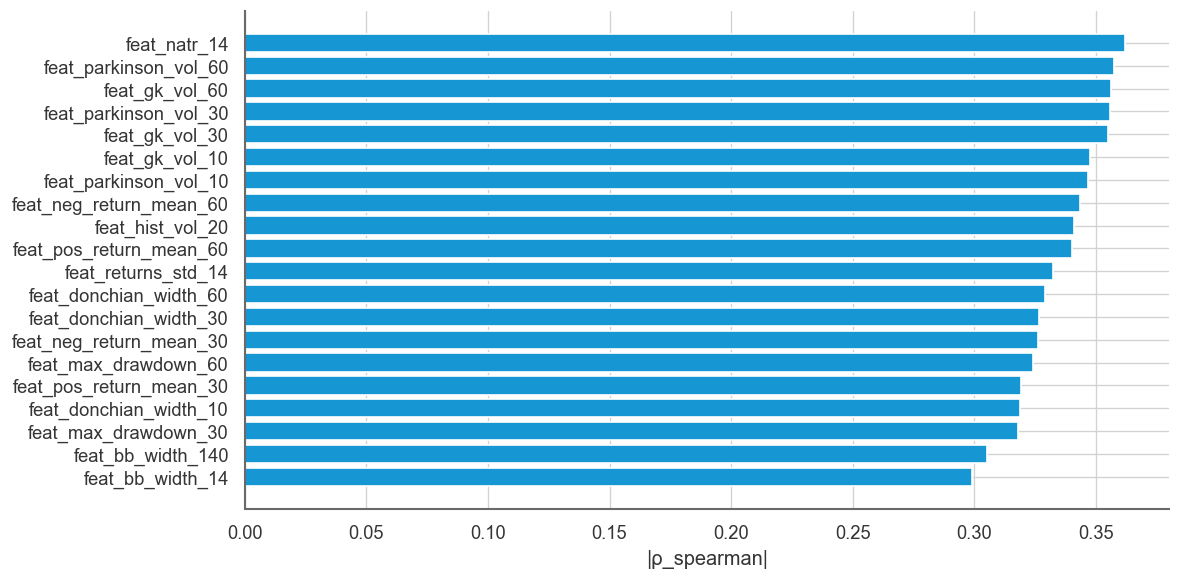

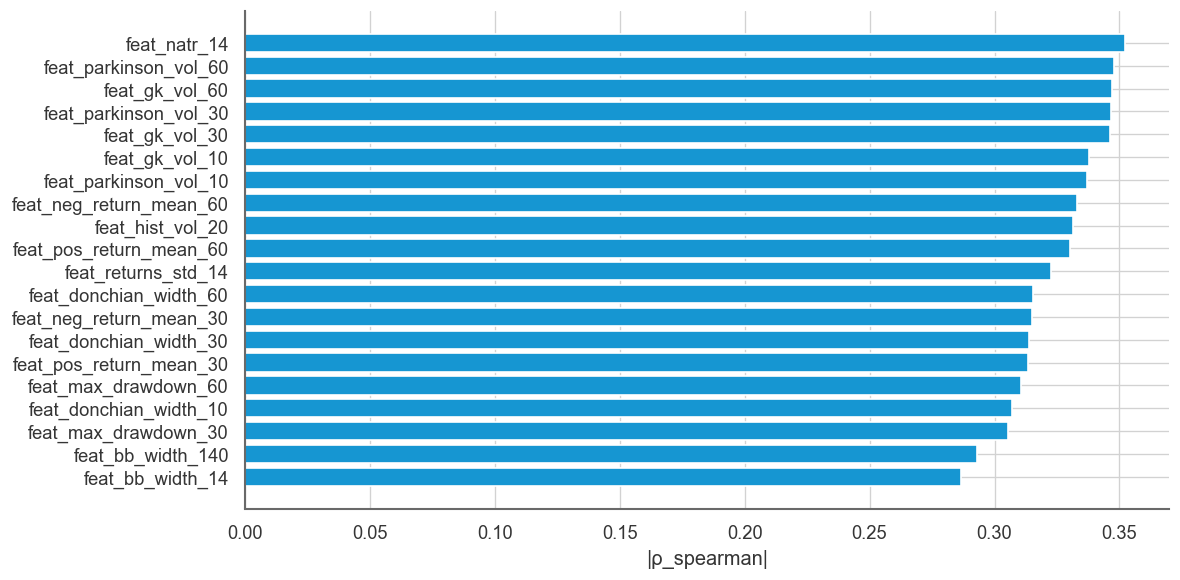

In [7]:
#| label: fig-relation-top20
#| fig-cap: "Top 20 feature signal_proxy értéke targetenként"
#| fig-alt: "Vízszintes oszlopdiagram: top 20 feature Spearman korrelációja long és short targettel"
#| fig-subcap:
#|   - "long_mfe_fw60"
#|   - "short_mfe_fw60"
#| layout-ncol: 1

for target in cfg.target_cols:
    sub = (
        relation_df
        .filter(pl.col("target") == target)
        .sort("signal_proxy", descending=True)
        .head(20)
    ).to_pandas()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(sub["feature"], sub["signal_proxy"], color=CQ_COLORS["blue"])
    ax.invert_yaxis()
    ax.set_xlabel("|ρ_spearman|")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

In [8]:
#| label: tbl-relation-nokeep
#| tbl-cap: "Nem-keep (feature, target) párok"

not_keep_r = relation_df.filter(pl.col("decision") != "keep").sort(["feature", "target"])
display(Markdown(f"**Nem-keep (feature, target) párok:** {len(not_keep_r)}"))
display_analysis_table(not_keep_r.to_pandas())

**Nem-keep (feature, target) párok:** 158

feature,target,pearson_r,spearman_rho,signal_proxy,leakage_flag,decision
feat_adx_neg_14,long_mfe_fw60,-0.024,-0.005,0.005,False,weak
feat_atr_dist_high_10,short_mfe_fw60,0.000,0.007,0.007,False,weak
feat_atr_dist_high_30,short_mfe_fw60,-0.022,0.005,0.005,False,weak
feat_atr_dist_high_60,short_mfe_fw60,-0.028,0.001,0.001,False,weak
feat_atr_dist_low_10,short_mfe_fw60,0.000,-0.001,0.001,False,weak
feat_atr_dist_low_30,short_mfe_fw60,0.019,0.005,0.005,False,weak
feat_bb_position_14,short_mfe_fw60,0.016,-0.003,0.003,False,weak
feat_bb_position_140,short_mfe_fw60,0.041,0.006,0.006,False,weak
feat_bb_width_rank_20,long_mfe_fw60,—,0.007,0.007,False,weak
feat_bb_width_rank_20,short_mfe_fw60,—,-0.004,0.004,False,weak


## Redundancy — Korrelációs klaszterezés

**Mi ez.** A `feat_*` oszlopokat Pearson korrelációs mátrix alapján klaszterezzük (union-find). Ha két feature |Pearson r| ≥ 0.95, egy klaszterbe kerülnek. Klaszterenként egy reprezentatív marad (`keep`), a többi `drop`.

**Forrás.** `quant_train` tábla, 500 000 véletlen sorból számított korrelációs mátrix.

**Értelmezés.** Reprezentatív = legkisebb indexű feature a klaszterben. A downstream `02_hyper_param_search.py` LightGBM feature importance-on keresztül tovább szűrhet.

In [9]:
#| label: tbl-redundancy-head
#| tbl-cap: "Redundancy analízis — top 10 sor"

redundancy_df = analyze_redundancy(conn, cfg)
display_analysis_table(redundancy_df.head(10).to_pandas())

12:37:37  INFO  analyze_redundancy: 208 features, sample=50000 / 3022801 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

12:38:09  INFO  analyze_redundancy: done — 208 clusters, 0 redundant features dropped


feature,cluster_id,is_representative,max_pearson,decision,drop_reason
feat_rsi_14,0,True,0.000,keep,nan
feat_roc_14,1,True,0.000,keep,nan
feat_roc_140,2,True,0.000,keep,nan
feat_stoch_k_14,3,True,0.000,keep,nan
feat_stoch_d_14,4,True,0.000,keep,nan
feat_williams_r_14,5,True,0.000,keep,nan
feat_cci_20,6,True,0.000,keep,nan
feat_adx_pos_14,7,True,0.000,keep,nan
feat_adx_neg_14,8,True,0.000,keep,nan
feat_adx_14,9,True,0.000,keep,nan


In [10]:
#| label: tbl-redundancy-dropped
#| tbl-cap: "Redundáns (drop) feature-ök klaszter szerinti bontásban"

n_clusters = redundancy_df["cluster_id"].n_unique()
n_multi    = (
    redundancy_df.group_by("cluster_id")
    .agg(pl.len().alias("n"))
    .filter(pl.col("n") > 1)
    .height
)
n_dropped  = (redundancy_df["decision"] == "drop").sum()

display(Markdown(
    f"**Klaszterek:** {n_clusters} összesen, {n_multi} darab >1 taggal — "
    f"**{n_dropped} redundáns feature kizárva.**"
))

dropped_red = redundancy_df.filter(pl.col("decision") == "drop").select(
    ["feature", "cluster_id", "max_pearson", "drop_reason"]
).sort("cluster_id")
display_analysis_table(dropped_red.to_pandas())

**Klaszterek:** 208 összesen, 0 darab >1 taggal — **0 redundáns feature kizárva.**

feature,cluster_id,max_pearson,drop_reason


## Stability — Időbeli stabilitás

**Mi ez.** Az adatot 90 napos, nem-átfedő időablakokra osztjuk. Minden (feature, bucket) párra Spearman korrelációt számítunk mindkét targettel és összehasonlítjuk a globális baseline-nal. `drift = |ρ_bucket − ρ_baseline|`.

**Forrás.** `quant_train` tábla, összes `feat_*` oszlop, 90 napos bucket-ek.

**Értelmezés.** `stable` ≤ 0.15; `review` 0.15–0.30; `unstable` > 0.30 (nem utolsó 2 bucket); `decayed` > 0.30 **és** utolsó 2 bucket → kizárjuk. A `decayed` flag azt jelenti, hogy a feature a legutóbbi adatszakaszban elveszítette prediktív kapcsolatát.

In [11]:
#| label: tbl-stability-head
#| tbl-cap: "Stability analízis — top 10 sor"

stability_df = analyze_stability(conn, cfg)
display(Markdown(f"**Összes (feature, bucket) sor:** {len(stability_df):,}"))
display_analysis_table(stability_df.head(10).to_pandas())

12:38:12  INFO  analyze_stability: 208 features, bucket_days=90, base_ts=2020-09-14 07:00:00


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

12:56:37  INFO  analyze_stability: done — 4176 (feature, bucket) rows


**Összes (feature, bucket) sor:** 4,176

feature,bucket_idx,bucket_start,bucket_end,n,null_rate,mean,std,spearman_long,spearman_short,drift_long,drift_short,stability_flag
feat_rsi_14,0,2020-09-14 07:00:00,2020-10-29 23:59:00,65820,0.02%,49.627,13.840,-0.006,0.040,0.013,0.040,stable
feat_rsi_14,1,2020-10-30 00:00:00,2021-01-26 23:59:00,128160,0.00%,50.329,12.863,0.006,0.029,0.026,0.029,stable
feat_rsi_14,2,2021-01-27 00:00:00,2021-04-27 23:59:00,131040,0.00%,50.796,12.898,0.055,0.067,0.075,0.066,stable
feat_rsi_14,3,2021-04-28 00:00:00,2021-07-25 23:59:00,128160,0.00%,50.081,11.177,-0.027,0.001,0.007,0.000,stable
feat_rsi_14,4,2021-07-26 00:00:00,2021-10-24 23:59:00,131040,0.00%,50.352,11.133,-0.029,-0.033,0.010,0.034,stable
feat_rsi_14,5,2021-10-25 00:00:00,2022-01-21 23:59:00,128160,0.00%,49.689,11.466,-0.031,-0.008,0.011,0.009,stable
feat_rsi_14,6,2022-01-22 00:00:00,2022-04-22 23:59:00,131040,0.00%,50.169,11.204,-0.018,0.000,0.002,0.000,stable
feat_rsi_14,7,2022-04-23 00:00:00,2022-07-20 23:59:00,128160,0.00%,49.696,11.288,-0.016,0.015,0.004,0.014,stable
feat_rsi_14,8,2022-07-21 00:00:00,2022-10-19 23:59:00,131040,0.00%,50.078,10.982,-0.051,-0.017,0.032,0.018,stable
feat_rsi_14,9,2022-10-20 00:00:00,2023-01-16 23:59:00,128160,0.00%,49.824,11.151,-0.003,-0.009,0.016,0.010,stable


In [12]:
#| label: fig-stability-drift
#| fig-cap: "Drift időbeli lefutása — decayed/unstable feature-ök mintája (max 6)"
#| fig-alt: "Vonaldiagram: drift értékek bucket-enként, long és short targetekre"
#| layout-ncol: 1

problematic = (
    stability_df
    .filter(pl.col("stability_flag").is_in(["decayed", "unstable"]))
    ["feature"].unique().to_list()
)

if not problematic:
    display(Markdown("**Nincs decayed/unstable feature** — minden feature stabilan tartja a prediktív kapcsolatát."))
else:
    sample_feats = sorted(problematic)[:6]
    for feat in sample_feats:
        sub = stability_df.filter(pl.col("feature") == feat).sort("bucket_idx").to_pandas()
        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(sub["bucket_idx"], sub["drift_long"],  marker="o", label="drift_long",  color=CQ_COLORS["blue"])
        ax.plot(sub["bucket_idx"], sub["drift_short"], marker="s", label="drift_short", color=CQ_COLORS["orange"])
        ax.axhline(cfg.max_drift_threshold, color=CQ_COLORS["red"], linestyle="--",
                   linewidth=1, label=f"threshold ({cfg.max_drift_threshold})")
        ax.legend(fontsize=8)
        ax.set_xlabel("bucket_idx")
        ax.set_ylabel("drift")
        ax.set_xlabel(f"{feat} — bucket_idx")
        plt.tight_layout()
        plt.show()

**Nincs decayed/unstable feature** — minden feature stabilan tartja a prediktív kapcsolatát.

In [13]:
#| label: tbl-stability-decayed
#| tbl-cap: "Decayed feature-ök összesítő statisztikái"

decayed_features = (
    stability_df
    .filter(pl.col("stability_flag") == "decayed")
    ["feature"].unique().to_list()
)
display(Markdown(f"**Decayed (kizárt) features:** {len(decayed_features)}"))

if decayed_features:
    decayed_summary = (
        stability_df
        .filter(pl.col("feature").is_in(decayed_features))
        .group_by("feature")
        .agg([
            pl.col("drift_long").max().alias("max_drift_long"),
            pl.col("drift_short").max().alias("max_drift_short"),
            pl.col("stability_flag")
              .filter(pl.col("stability_flag") == "decayed")
              .len().alias("decayed_buckets"),
        ])
        .sort("max_drift_long", descending=True)
    )
    display_analysis_table(decayed_summary.to_pandas())

**Decayed (kizárt) features:** 0

## Output — feature_set.json

**Mi ez.** A 4 lépés eredményét kombináljuk. Egy feature a `selected` listába kerül, ha: (1) quality → `keep`, (2) target_relation → legalább egy targetre `keep`, (3) redundancy → `keep`, (4) stability → nincs `decayed` bucket.

**Forrás.** A fenti 4 analízis lépés kimenetei.

**Értelmezés.** A `selected` lista adódik tovább a `00_create_sample.py`-nak. `dropped` okkal, `review` marginális (megtartjuk, de jelölt).

In [ ]:
conn.close()
output_dir.mkdir(parents=True, exist_ok=True)

all_features = quality_df["feature"].to_list()
created_at   = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

quality_drop   = {r["feature"]: r["drop_reason"] for r in quality_df.iter_rows(named=True) if r["decision"] == "drop"}
quality_review = {r["feature"] for r in quality_df.iter_rows(named=True) if r["decision"] == "review"}

relation_keep = {r["feature"] for r in relation_df.iter_rows(named=True) if r["decision"] == "keep"}
relation_leak = {r["feature"] for r in relation_df.iter_rows(named=True) if r["decision"] == "leakage"}

redundancy_drop = {r["feature"]: r["drop_reason"] for r in redundancy_df.iter_rows(named=True) if r["decision"] == "drop"}

decayed_set  = {r["feature"] for r in stability_df.iter_rows(named=True) if r["stability_flag"] == "decayed"}
unstable_set = {r["feature"] for r in stability_df.iter_rows(named=True) if r["stability_flag"] in ("unstable", "review")} - decayed_set

# Expert filter: permanently exclude time-of-day / session-anchored features
expert_excluded = {
    feat: "expert: time-of-day / session-anchored feature"
    for feat in all_features
    if any(pat in feat for pat in cfg.expert_exclude_patterns)
}

selected: list[str]  = []
dropped:  list[dict] = []
review:   list[str]  = []

for feat in all_features:
    if feat in expert_excluded:
        dropped.append({"col": feat, "reason": expert_excluded[feat]})
        continue

    reasons: list[str] = []
    if feat in quality_drop:
        reasons.append(f"quality: {quality_drop[feat]}")
    if feat in relation_leak:
        reasons.append("relation: leakage suspect")
    if feat not in relation_keep and feat not in relation_leak:
        reasons.append("relation: weak signal across all targets")
    if feat in redundancy_drop:
        reasons.append(f"redundancy: {redundancy_drop[feat]}")
    if feat in decayed_set:
        reasons.append("stability: decayed in recent buckets")

    is_review = (feat in quality_review or feat in unstable_set) and not reasons

    if reasons:
        dropped.append({"col": feat, "reason": " | ".join(reasons)})
    elif is_review:
        review.append(feat)
    else:
        selected.append(feat)

fs = {
    "run_id"     : cfg.run_id,
    "asset_id"   : cfg.asset_id,
    "target_col" : cfg.target_cols[0],
    "created_at" : created_at,
    "target_cols": list(cfg.target_cols),
    "selected"   : selected,
    "dropped"    : dropped,
    "review"     : review,
    "thresholds" : {
        "max_null_rate"          : cfg.max_null_rate,
        "max_inf_rate"           : cfg.max_inf_rate,
        "min_variance"           : cfg.min_variance,
        "max_outlier_ratio"      : cfg.max_outlier_ratio,
        "min_spearman_abs"       : cfg.min_spearman_abs,
        "max_spearman_leakage"   : cfg.max_spearman_leakage,
        "pearson_cluster_thr"    : cfg.pearson_cluster_thr,
        "redundancy_max_rows"    : cfg.redundancy_max_rows,
        "stability_bucket_days"  : cfg.stability_bucket_days,
        "max_drift_threshold"    : cfg.max_drift_threshold,
        "expert_exclude_patterns": list(cfg.expert_exclude_patterns),
    },
}

json_path = output_dir / "feature_set.json"
json_path.write_text(json.dumps(fs, indent=2), encoding="utf-8")

In [15]:
#| label: tbl-output-summary
#| tbl-cap: "Feature szelekció végeredmény"

summary_df = pd.DataFrame([
    {"kategória": "selected", "count": len(selected)},
    {"kategória": "review",   "count": len(review)},
    {"kategória": "dropped",  "count": len(dropped)},
])
display_analysis_table(summary_df)

display(Markdown(
    f"**Output:** `{output_dir}` → `feature_set.json` ✓"
))

kategória,count
selected,156
review,11
dropped,41


**Output:** `D:\repos\chronoquant\database\solusdt\feature_engineering\run_20260619_122555` → `feature_set.json` ✓

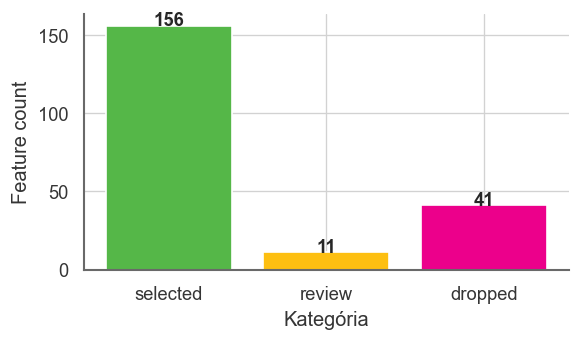

In [16]:
#| label: fig-output-summary
#| fig-cap: "Feature szelekció végeredmény — megoszlás"
#| fig-alt: "Oszlopdiagram: selected/review/dropped feature count"

fig, ax = plt.subplots(figsize=(5, 3))
cats   = ["selected", "review", "dropped"]
values = [len(fs["selected"]), len(fs["review"]), len(fs["dropped"])]
colors = [CQ_COLORS["green"], CQ_COLORS["yellow"], CQ_COLORS["red"]]
ax.bar(cats, values, color=colors)
ax.set_xlabel("Kategória")
ax.set_ylabel("Feature count")
for i, v in enumerate(values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()